# New York City Airbnb 2019 Analysis 🏙️

This notebook explores Airbnb listing data from New York City in 2019. The goal is to clean and prepare the data for further analysis, and ultimately understand how pricing, room types, and availability vary across the five boroughs of NYC.

New York City is one of the most active short-term rental markets in the world. With over 48,000 listings across Manhattan, Brooklyn, Queens, the Bronx, and Staten Island, this dataset offers a rich opportunity to uncover pricing patterns and rental trends across different neighborhoods.

## Dataset Description

This dataset comes from **Inside Airbnb**, a public data project that collects and analyzes Airbnb listing data. It was also made available on Kaggle and contains information on active Airbnb listings in NYC for the year 2019.

**Source:** Inside Airbnb / Kaggle

**URL:** https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

**Year:** 2019

### Key Features:
- **neighbourhood_group:** The borough where the listing is located
- **neighbourhood:** The specific neighbourhood of the listing
- **room_type:** The type of room offered (Entire home/apt, Private room, Shared room)
- **price:** The nightly price of the listing in USD
- **minimum_nights:** The minimum number of nights required to book
- **number_of_reviews:** Total number of reviews the listing has received
- **reviews_per_month:** Average number of reviews per month
- **calculated_host_listings_count:** Number of listings the host has
- **availability_365:** Number of days the listing is available per year
- **last_review:** Date of the most recent review

## 1. Data Cleaning and Wrangling

Let's load the data and check a brief description of our data:

In [ ]:
# Import all necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [ ]:
# Load NYC Airbnb 2019 dataset directly from GitHub raw link
airbnb_data = pd.read_csv('https://raw.githubusercontent.com/mansour927/AB_NYC_2019/main/ab_nyc_2019.csv')
airbnb_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Now let's observe a brief description of our data:

In [ ]:
# Check column names data types and non-null counts

airbnb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

Let's adjust the data types for the categorical columns by converting them to string type for consistency:

In [ ]:
# Convert categorical columns from object to string type for consistency
airbnb_data = airbnb_data.astype({
    'name': 'string',
    'host_name': 'string',
    'neighbourhood_group': 'string',
    'neighbourhood': 'string',
    'room_type': 'string'
})
airbnb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  string 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  string 
 4   neighbourhood_group             48895 non-null  string 
 5   neighbourhood                   48895 non-null  string 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  string 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

Since we don't have NA values, let's double check for duplicate rows:

In [ ]:
# Check for duplicate rows in the dataset
airbnb_data.duplicated().sum()

np.int64(0)

Given the sum is 0 there are no duplicate rows. Now let's check the missing values in our dataset:

In [ ]:
# Check number of missing values in each column
airbnb_data.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


We can see that last_review and reviews_per_month both have about 20% missing values, while name and host_name have less than 1% missing. Let's drop the columns that are not needed for the analysis:

In [ ]:
# id and host_id are identifier numbers not useful for analysis
# latitude and longitude are geographic coordinates we won't use
# last_review has more than 20% missing values
airbnb_data = airbnb_data.drop(columns=['id', 'host_id', 'latitude', 'longitude', 'last_review'])
airbnb_data.head()

,name,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,Private room,150,3,0,NaN,1,365
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,1,0


In [ ]:
# Verify remaining missing values after dropping columns
airbnb_data.isnull().sum()

,0
name,16
host_name,21
neighbourhood_group,0
neighbourhood,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,10052
calculated_host_listings_count,0


Now let's explore the unique entries in a few of the columns to better understand what we are working with:

In [ ]:
# Check unique boroughs in the dataset
airbnb_data['neighbourhood_group'].unique()

<StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: string

In [ ]:
# Check unique room types in the dataset
airbnb_data['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: string

In [ ]:
# Count number of listings per borough
airbnb_data['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


The dataset covers all five boroughs of New York City. Manhattan has the highest number of listings followed by Brooklyn. Now let's handle the remaining missing values:

The name and host_name columns have less than 1% missing values. Since they are categorical we will impute them with the mode:

In [ ]:
# Impute name and host_name with mode since less than 1% missing
mode_name = airbnb_data['name'].mode()[0]
airbnb_data['name'] = airbnb_data['name'].fillna(mode_name)

mode_host = airbnb_data['host_name'].mode()[0]
airbnb_data['host_name'] = airbnb_data['host_name'].fillna(mode_host)

I also noticed that the price column has some listings with a price of 0 which is not realistic for an Airbnb listing. I will remove these rows:

In [ ]:
# Remove listings with price of 0 since they are not realistic
print(f'Rows with price = 0: {(airbnb_data["price"] == 0).sum()}')
airbnb_data = airbnb_data[airbnb_data['price'] > 0].copy()
print(f'Rows remaining: {airbnb_data.shape[0]:,}')

Rows with price = 0: 11
Rows remaining: 48,884


The reviews_per_month column has about 20% missing values. These missing values come from listings that have never received a review so there is no monthly average to calculate. Since the data is right skewed I will impute with the median:

In [ ]:
# Impute reviews_per_month with median since data is right skewed
median_reviews = airbnb_data['reviews_per_month'].median()
airbnb_data['reviews_per_month'] = airbnb_data['reviews_per_month'].fillna(median_reviews)
airbnb_data.isnull().sum()

,0
name,0
host_name,0
neighbourhood_group,0
neighbourhood,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


### Categorizing Listing Prices

To get a better understanding of the pricing landscape I categorized each listing into one of three price groups based on the nightly rate:

- Budget: Less than 100 USD per night
- Moderate: Between 100 and 250 USD per night
- Luxury: Greater than 250 USD per night

In [ ]:
#Categorizing different price
def categorize_price(price):
    if price < 100:
        return 'Budget'
    elif price <= 250:
        return 'Moderate'
    else:
        return 'Luxury'

airbnb_data['Price_Category'] = airbnb_data['price'].apply(categorize_price)
airbnb_data.head()

,name,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,Price_Category
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365,Moderate
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355,Moderate
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,Private room,150,3,0,0.72,1,365,Moderate
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194,Budget
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,1,0,Budget


Let's see how many listings fall in each price category:

In [ ]:
# Count listings in each price category
airbnb_data['Price_Category'].value_counts()

,count
Price_Category,
Budget,21866
Moderate,21810
Luxury,5208


Let's take a look at the descriptive statistics of our cleaned dataset:

In [ ]:
# Summary statistics for all columns in the cleaned dataset
airbnb_data.describe(include='all')

,name,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,Price_Category
count,48884,48884,48884,48884,48884,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884
unique,47894,11450,5,221,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,NaN,NaN,NaN,NaN,NaN,NaN,Budget
freq,34,438,21660,3919,25407,NaN,NaN,NaN,NaN,NaN,NaN,21866
mean,NaN,NaN,NaN,NaN,NaN,152.755053,7.029887,23.271991,1.238839,7.144628,112.779498,NaN
std,NaN,NaN,NaN,NaN,NaN,240.170260,20.512224,44.551331,1.520788,32.956185,131.627271,NaN
min,NaN,NaN,NaN,NaN,NaN,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,69.000000,1.000000,1.000000,0.280000,1.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000,NaN


In [ ]:
airbnb_data.isnull().sum()

,0
name,0
host_name,0
neighbourhood_group,0
neighbourhood,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


Let's use a pairplot to get a preliminary look at the relationships between the numerical columns in our dataset:





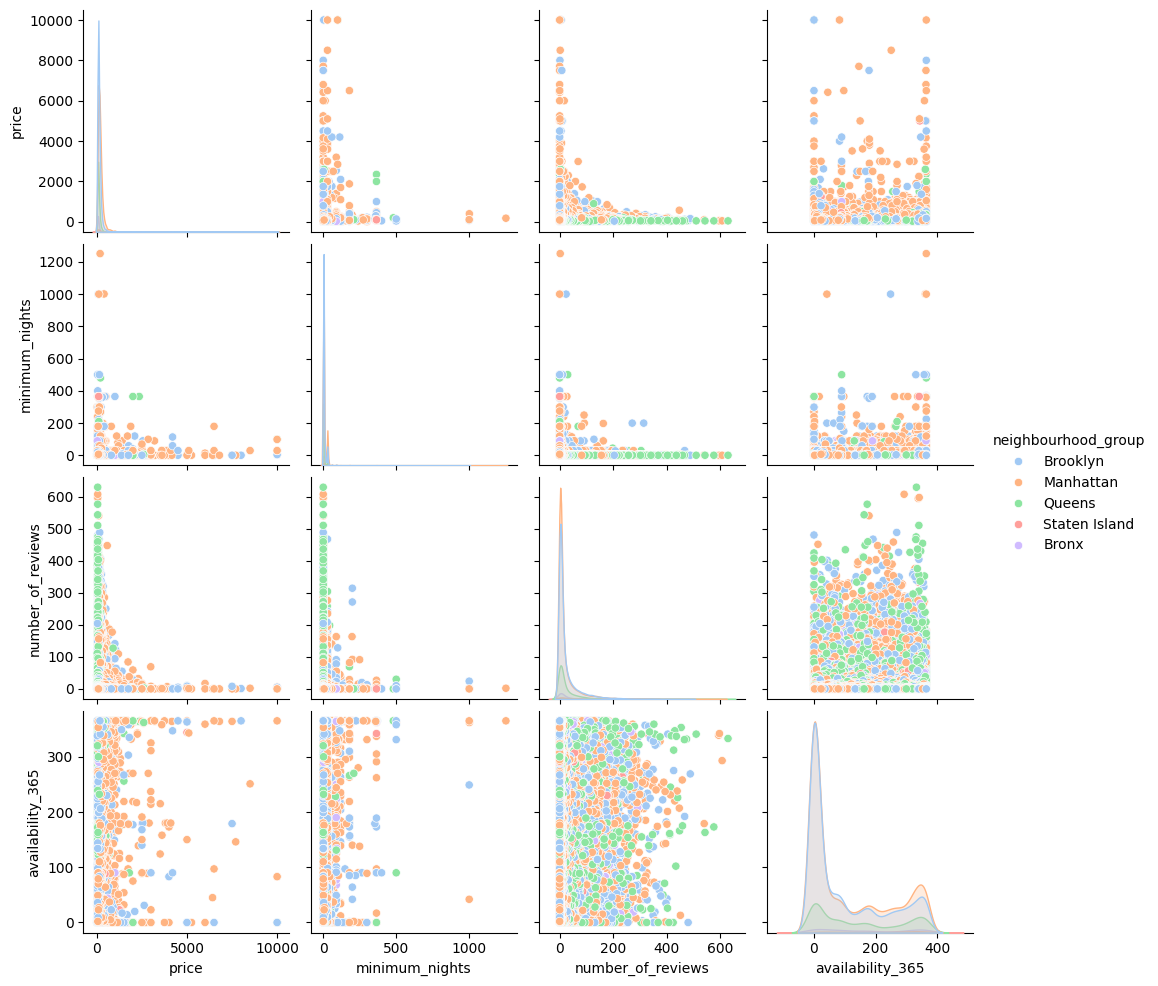

In [ ]:
# Pairplot to explore relationships between numerical columns colored by borough
sns.pairplot(airbnb_data[['price', 'minimum_nights', 'number_of_reviews',
                           'availability_365', 'neighbourhood_group']],
             hue='neighbourhood_group', palette='pastel')
plt.show()

From the pairplot I can see that price and minimum_nights both have extreme outliers where a small number of listings have very high values compared to the majority. Most listings are clustered at low prices and short minimum night requirements. Manhattan listings tend to appear at higher price points compared to Brooklyn, Queens, the Bronx and Staten Island. The number_of_reviews column shows that most listings have very few reviews with only a small number of highly active listings having over 400 reviews. The availability_365 column is more evenly spread across all boroughs showing that hosts manage their availability differently regardless of location.

#Visualizations

### Exploring Price Differences Across NYC Boroughs

In this section I will analyze how Airbnb listing prices vary across the five boroughs of New York City. The goal is to understand if certain boroughs consistently have higher or lower prices and whether price variability differs across locations.

The boxplot below displays the distribution of nightly prices for each borough.

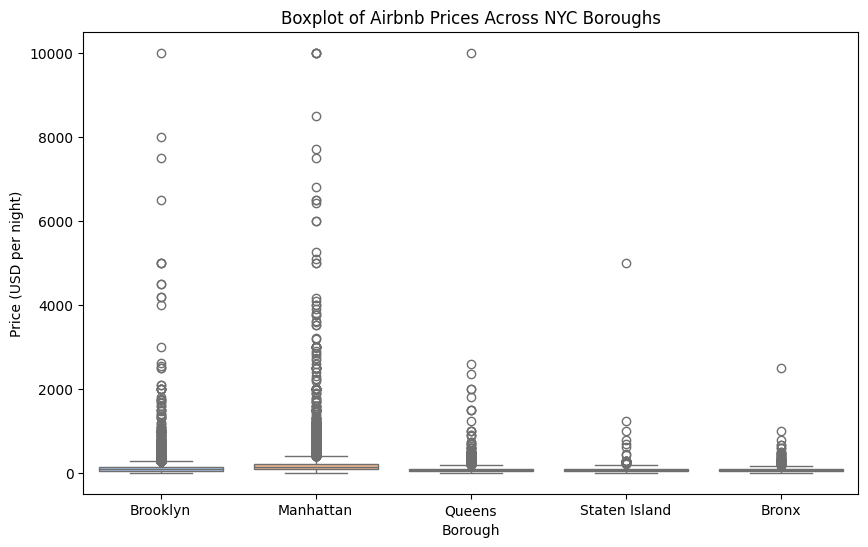

In [ ]:
# Boxplot of price distribution across boroughs
plt.figure(figsize=(10, 6))
sns.boxplot(x='neighbourhood_group', y='price',
            data=airbnb_data,
            hue='neighbourhood_group',
            palette='pastel')
plt.title('Boxplot of Airbnb Prices Across NYC Boroughs')
plt.xlabel('Borough')
plt.ylabel('Price (USD per night)')
plt.show()

We can see that the extreme outliers are making it difficult to read the actual price distribution for each borough. Let's observe the boxplot without listings priced above 500 USD per night to get a clearer picture:

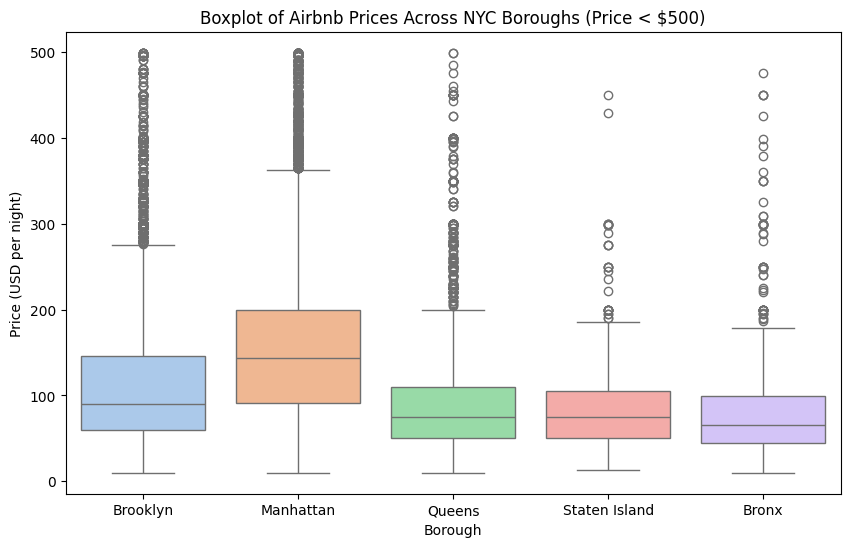

In [ ]:
# Filter out extreme outliers for better visualization
airbnb_filtered = airbnb_data[airbnb_data['price'] < 500].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(x='neighbourhood_group', y='price',
            data=airbnb_filtered,
            hue='neighbourhood_group',
            palette='pastel')
plt.title('Boxplot of Airbnb Prices Across NYC Boroughs (Price < $500)')
plt.xlabel('Borough')
plt.ylabel('Price (USD per night)')
plt.show()

It seems that our suspicion was correct. `Manhattan` has the highest median price at around `150 USD` per night followed by `Brooklyn` at around `90 USD` per night. `Queens`, `Staten Island` and `the Bronx` have similar and lower median prices. `Manhattan` also has the widest box indicating more variability in pricing compared to other boroughs. All boroughs still show outliers even after filtering which suggests that premium listings exist across all of NYC not just in Manhattan.

### Average Price by Room Type

In this visualization I want to understand how the type of room affects the nightly price in NYC. The three room types available on Airbnb are Entire home/apt, Private room and Shared room. The goal is to see which room type commands the highest average price and by how much it differs from the others.

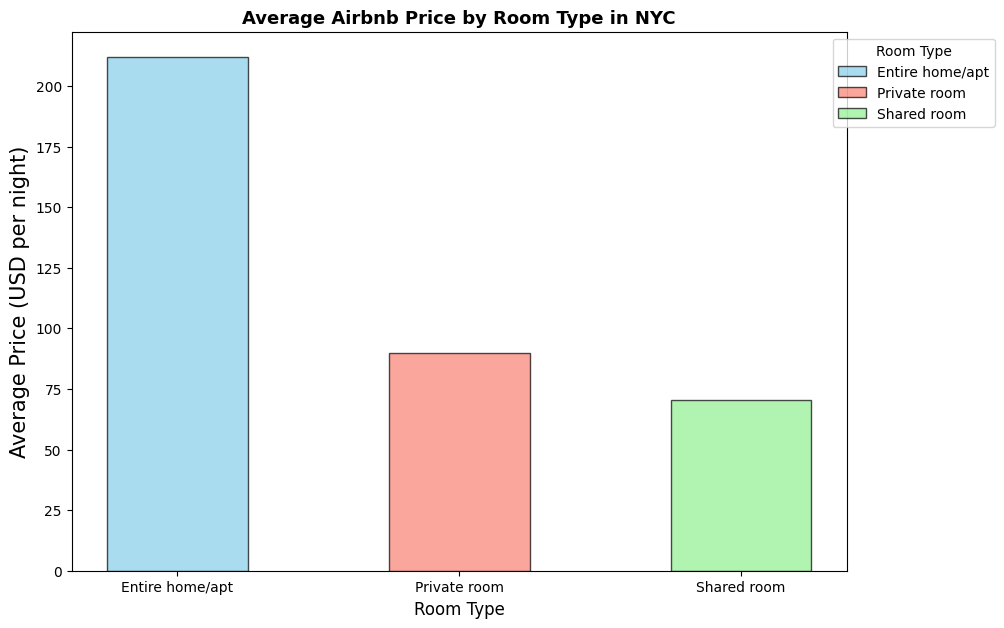

In [ ]:
# Calculate average price per room type
avg_price_room = airbnb_data.groupby('room_type')['price'].mean().reset_index()

# Set the figure size for better visibility
plt.figure(figsize=(10, 7))


bars = plt.bar(avg_price_room['room_type'], avg_price_room['price'],
               color=['skyblue', 'salmon', 'lightgreen'],
               alpha=0.7,
               edgecolor='black',
               width=0.5)


plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Average Price (USD per night)', fontsize=15)
plt.title('Average Airbnb Price by Room Type in NYC', fontsize=13, fontweight='bold')


plt.legend(bars, ['Entire home/apt', 'Private room', 'Shared room'],
           title='Room Type', loc='upper right', bbox_to_anchor=(1.2, 1))


plt.show()

Entire home listings have the highest average nightly price at around 212 USD per night which is more than double the average price of a private room at around 90 USD per night. Shared rooms are the most affordable option averaging around 70 USD per night. This makes sense since renting an entire home gives guests full privacy and more space while shared rooms offer the least privacy. This suggests that guests who want privacy pay significantly more for their stay in NYC.

### Price vs Reviews per Month by Borough

In this visualization I want to explore whether more expensive listings tend to get booked less frequently. I will use reviews per month as a measure of booking activity since listings that get booked more often tend to receive more reviews. The goal is to see if there is a relationship between price and booking frequency and whether this pattern differs across the five boroughs of NYC.

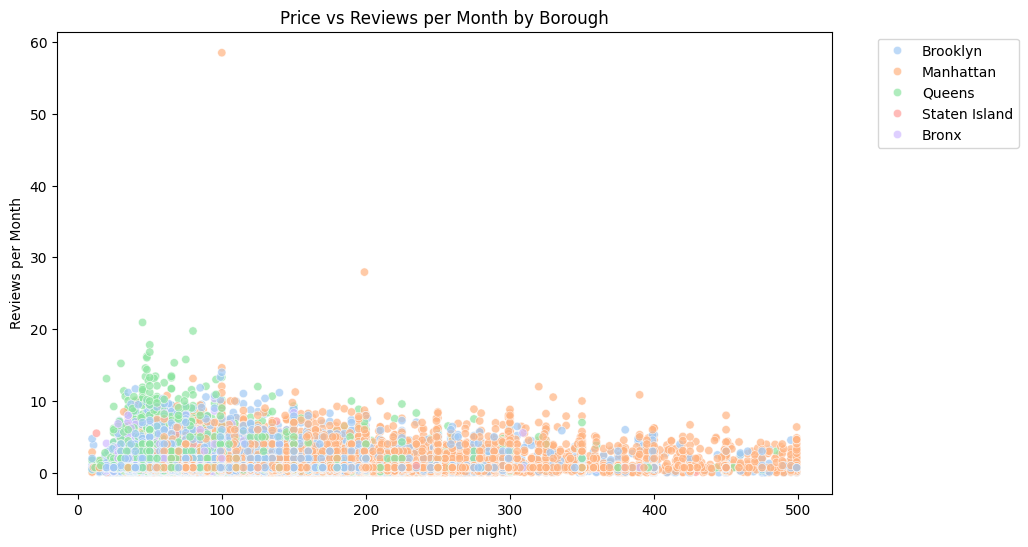

In [ ]:
# Filter listings under 500 USD for better visualization
airbnb_filtered = airbnb_data[airbnb_data['price'] < 500]

# Scatter plot of price vs reviews per month colored by borough
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='reviews_per_month',
                hue='neighbourhood_group',
                data=airbnb_filtered,
                palette='pastel',
                alpha=0.7)

# Adding titles and labels
plt.title('Price vs Reviews per Month by Borough')
plt.xlabel('Price (USD per night)')
plt.ylabel('Reviews per Month')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.5)
plt.show()

Most listings across all boroughs are clustered at lower price points with fewer than 10 reviews per month. Queens listings shown in green tend to have the highest reviews per month at lower price points suggesting they get booked very frequently. Manhattan listings shown in orange are spread across all price ranges reflecting the diversity of listings in that borough. As price increases beyond 200 USD per night the number of reviews per month drops significantly across all boroughs suggesting that higher priced listings get booked less frequently.

## Proportions (Probabilities) Based on the Observed Data

In this section I will calculate sample based probabilities directly from the dataset. These are not theoretical probabilities but estimates based on what we observe in our sample data.

### What is the probability that a random listing in our dataset is located in Manhattan?

In [ ]:
# Filter listings in Manhattan and calculate simple probability
filter_manhattan = airbnb_data['neighbourhood_group'] == 'Manhattan'
airbnb_manhattan = airbnb_data[filter_manhattan]

# Calculate probability
prob_manhattan = len(airbnb_manhattan) / len(airbnb_data)

print(f'The probability that a random listing is located in Manhattan is: {prob_manhattan*100:.2f}%')

The probability that a random listing is located in Manhattan is: 44.31%


Based on our sample data about 44% of all Airbnb listings in NYC are located in Manhattan. This is a sample estimate based on our observed data.

What is the probability that a random listing in our dataset is an Entire home and located in Manhattan?

In [ ]:
# Separating the conditions for better readability
condition1 = airbnb_data['room_type'] == 'Entire home/apt'
condition2 = airbnb_data['neighbourhood_group'] == 'Manhattan'

# Combine conditions using AND
filter_entire_manhattan = condition1 & condition2
airbnb_entire_manhattan = airbnb_data[filter_entire_manhattan]
airbnb_entire_manhattan.head()

,name,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,Price_Category
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355,Moderate
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,0.10,1,0,Budget
5,Large Cozy 1 BR Apartment In Midtown East,Chris,Manhattan,Murray Hill,Entire home/apt,200,3,74,0.59,1,129,Moderate
9,Cute & Cozy Lower East Side 1 bdrm,Ben,Manhattan,Chinatown,Entire home/apt,150,1,160,1.33,4,188,Moderate
10,Beautiful 1br on Upper West Side,Lena,Manhattan,Upper West Side,Entire home/apt,135,5,53,0.43,1,6,Moderate


In [ ]:
# Calculate probability
prob_entire_manhattan = len(airbnb_entire_manhattan) / len(airbnb_data)

print(f'The probability that a random listing is an Entire home AND located in Manhattan is: {prob_entire_manhattan*100:.2f}%')

The probability that a random listing is an Entire home AND located in Manhattan is: 27.00%


Based on our sample about 27% of all listings in NYC are entire home listings located in Manhattan.This is a sample estimate based on our observed data.

What is the probability that a random listing in our dataset is a Private room OR located in Brooklyn?

In [ ]:
# Separating the conditions for better readability
condition1 = airbnb_data['room_type'] == 'Private room'
condition2 = airbnb_data['neighbourhood_group'] == 'Brooklyn'

# Combine conditions using OR
filter_private_or_brooklyn = condition1 | condition2
airbnb_private_or_brooklyn = airbnb_data[filter_private_or_brooklyn]
airbnb_private_or_brooklyn.head()

,name,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,Price_Category
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365,Moderate
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,Private room,150,3,0,0.72,1,365,Moderate
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,4.64,1,194,Budget
6,BlissArtsSpace!,Garon,Brooklyn,Bedford-Stuyvesant,Private room,60,45,49,0.40,1,0,Budget
7,Large Furnished Room Near B'way,Shunichi,Manhattan,Hell's Kitchen,Private room,79,2,430,3.47,1,220,Budget


In [ ]:
# Calculate OR probability P(Private room OR Brooklyn
prob_private_or_brooklyn = len(airbnb_private_or_brooklyn) / len(airbnb_data)

print(f'The probability that a random listing is a Private room OR located in Brooklyn is: {prob_private_or_brooklyn*100:.2f}%')

The probability that a random listing is a Private room OR located in Brooklyn is: 66.05%


Based on our sample about 66% of all listings in NYC are either a private room or located in Brooklyn or both.This is a sample estimate based on our observed data.

What is the probability that a listing is Luxury given that it is located in Manhattan?

In [ ]:
# Create contingency table for borough and price category with row and column totals
contingency_table = pd.crosstab(airbnb_data['neighbourhood_group'],
                                airbnb_data['Price_Category'],
                                margins=True, margins_name='Total')
contingency_table

Price_Category,Budget,Luxury,Moderate,Total
neighbourhood_group,,,,
Bronx,822,34,234,1090
Brooklyn,10895,1214,7986,20095
Manhattan,6035,3744,11881,21660
Queens,3865,198,1603,5666
Staten Island,249,18,106,373
Total,21866,5208,21810,48884


In [ ]:
# Calculate P(Luxury | Manhattan) directly from the contingency table
prob_luxury_given_manhattan = contingency_table.loc['Manhattan', 'Luxury'] / contingency_table.loc['Manhattan', 'Total']

print(f'The probability that a listing is Luxury given that it is in Manhattan is: {prob_luxury_given_manhattan*100:.2f}%')

The probability that a listing is Luxury given that it is in Manhattan is: 17.29%


Based on our sample about 17% of Manhattan listings are classified as Luxury meaning they cost more than 250 USD per night. This is a sample estimate based on our observed data.

What is the probability that a listing is in Brooklyn given that it is a Budget listing?

In [ ]:
# Using the same contingency table from before
# Calculate P(Brooklyn | Budget) directly from the contingency table
prob_brooklyn_given_budget = contingency_table.loc['Brooklyn', 'Budget'] / contingency_table.loc['Total', 'Budget']

print(f'The probability that a listing is in Brooklyn given that it is a Budget listing is: {prob_brooklyn_given_budget*100:.2f}%')

The probability that a listing is in Brooklyn given that it is a Budget listing is: 49.83%


Based on our sample about 50% of all Budget listings in NYC are located in Brooklyn. This means that if a listing is priced under 100 USD per night there is roughly a 1 in 2 chance it is in Brooklyn. Brooklyn clearly dominates the affordable segment of the NYC Airbnb market. This is a sample estimate based on our observed data.

## Probabilities Based on the Normal Distribution Model

Before I can use the normal distribution model I need to check if any of the columns in my dataset are approximately normally distributed. Let me start by looking at the histograms:

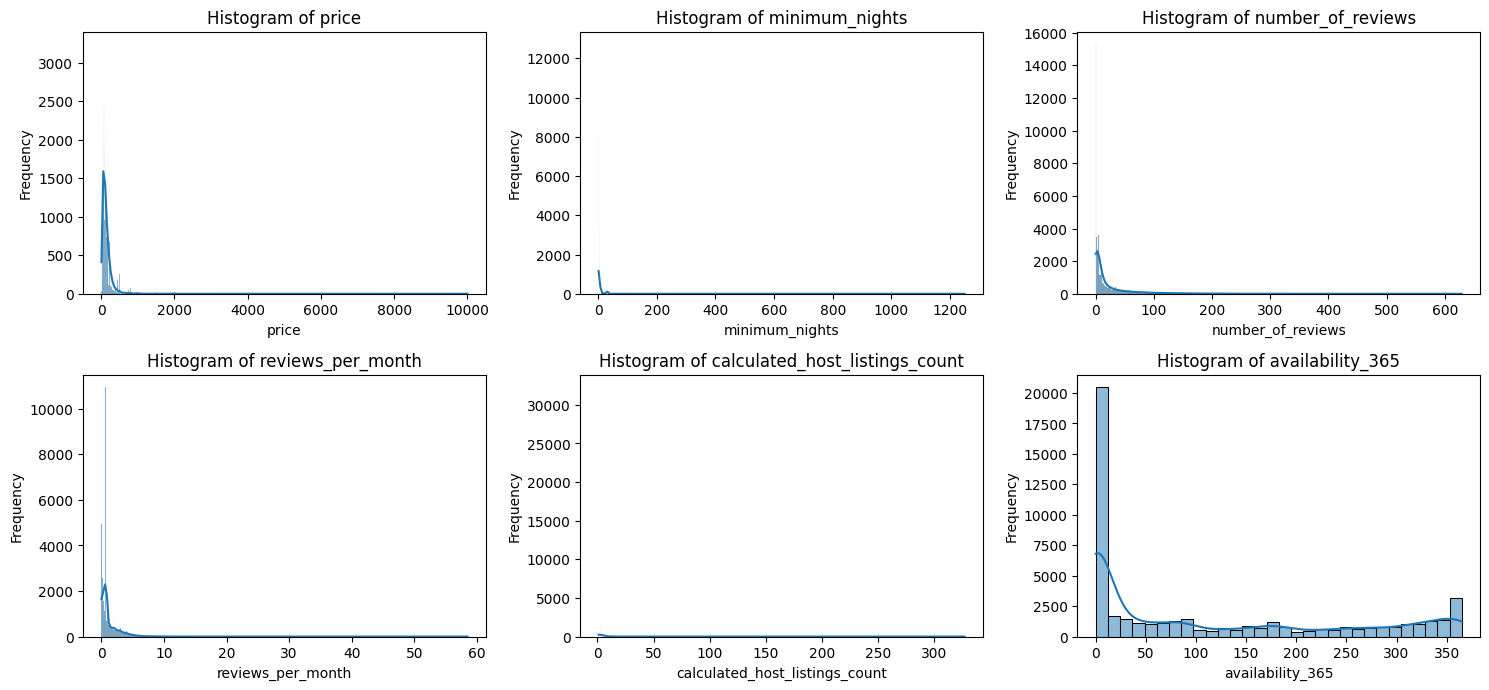

In [ ]:
# Plot histograms for all numerical columns to check for normality
numerical_cols = airbnb_data.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(airbnb_data[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Looking at the histograms most columns are heavily right skewed. The reviews_per_month column looks like it could be the closest to normal. Let me check it more carefully using a QQ plot:

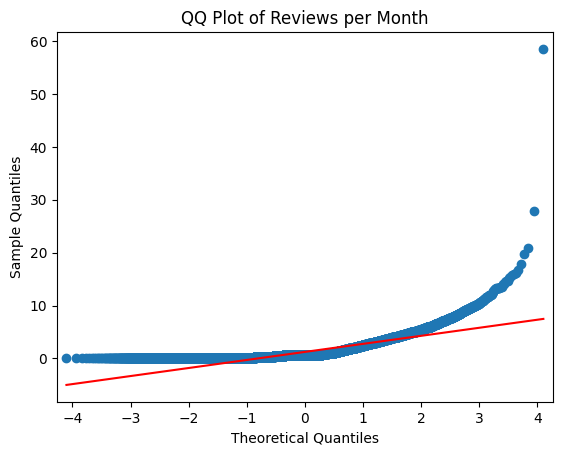

In [ ]:
import statsmodels.api as sm

# QQ plot for reviews_per_month
sm.qqplot(airbnb_data['reviews_per_month'], line='s')
plt.title('QQ Plot of Reviews per Month')
plt.show()

The QQ plot shows that the data does not follow a straight line especially at the tails which means it is not perfectly normal. Let me run a Shapiro-Wilk test to confirm:

In [ ]:
from scipy.stats import shapiro

# Shapiro-Wilk test on a sample since our dataset is large
# For large datasets we take a sample first
sample_reviews = airbnb_data['reviews_per_month'].sample(500, random_state=2025)
p_value = shapiro(sample_reviews)

print(f'The p-value for the Shapiro-Wilk test is: {p_value[1]:.4f}')

The p-value for the Shapiro-Wilk test is: 0.0000


The p-value is less than 0.05 which means the data is not normally distributed. Since none of my columns are normally distributed I will use the Central Limit Theorem instead. This means I will take samples from my data and ask questions about the sample mean rather than individual values.

### Question 1: What is the probability that a random sample of 50 listings has a mean price greater than 160 USD per night?

In [ ]:
# Mean and standard deviation of price column
mean_price = airbnb_data['price'].mean()
std_price = airbnb_data['price'].std()
n = 50

# Standard error of the mean
se = std_price / np.sqrt(n)


probability = 1 - stats.norm.cdf(160, mean_price, se)

print(f'The probability that the sample mean price for 50 random listings is above 160 USD is: {probability*100:.1f}%')

The probability that the sample mean price for 50 random listings is above 160 USD is: 41.6%


There is a 41.6% chance that a random sample of 50 listings will have a mean price greater than 160 USD per night. This means that if we randomly selected 50 listings from our dataset about 4 out of 10 times the average price would exceed 160 USD. This makes sense given that the overall mean price in our dataset is around 152 USD per night so 160 USD is slightly above average.

### Question 2

What is the probability that a random sample of 50 listings has a mean price between 140 and 170 USD per night?

In [ ]:
# Probability of sample mean falling between 140 and 170 USD
# Subtract lower CDF from upper CDF to get the area in between
probability2 = stats.norm.cdf(170, mean_price, se) - stats.norm.cdf(140, mean_price, se)

print(f'The probability that the sample mean price for 50 random listings is between 140 and 170 USD is: {probability2*100:.1f}%')

The probability that the sample mean price for 50 random listings is between 140 and 170 USD is: 34.1%


There is a 34.1% chance that a random sample of 50 listings will have a mean price between 140 and 170 USD per night. This range is centered around the overall mean price of our dataset which is around 152 USD per night. So about 1 in 3 random samples of 50 listings would fall within this price range on average.

### Question 3

What is the probability that a random sample of 50 listings has a mean reviews per month less than 1.5?

In [ ]:
# Mean and standard deviation of reviews_per_month column
# P(sample mean reviews per month < 1.5) using CLT
mean_reviews = airbnb_data['reviews_per_month'].mean()
std_reviews = airbnb_data['reviews_per_month'].std()
n = 50

# Standard error of the mean
se_reviews = std_reviews / np.sqrt(n)

probability3 = stats.norm.cdf(1.5, mean_reviews, se_reviews)

print(f'The probability that the sample mean reviews per month for 50 random listings is less than 1.5 is: {probability3*100:.1f}%')

The probability that the sample mean reviews per month for 50 random listings is less than 1.5 is: 88.8%


There is an 88.8% chance that a random sample of 50 listings will have a mean reviews per month less than 1.5. This is a very high probability which makes sense since most listings in our dataset receive fewer than 1.5 reviews per month on average. This suggests that the majority of Airbnb listings in NYC are not frequently booked or reviewed on a monthly basis.

## Confidence Intervals

In this section I will calculate confidence intervals to estimate the true population parameters based on our sample data. Since we do not know the population standard deviation I will use the t-distribution for the mean confidence intervals and the normal distribution for the proportion confidence interval.

## 5. Confidence Intervals

### Confidence Interval 1: Mean Nightly Price of Airbnb Listings in NYC

I want to estimate the true average nightly price of all Airbnb listings in NYC. Since the population standard deviation is unknown I will use the sample standard deviation and apply the t-distribution.

In [ ]:
# Sample statistics for price
n = len(airbnb_data['price'])
mean_price = airbnb_data['price'].mean()
std_price = airbnb_data['price'].std()

confidence_level = 0.95
alpha = 1 - confidence_level

# Critical t value
t_critical = stats.t.ppf(1 - alpha/2, df=n-1)

# Margin of error
margin_of_error = t_critical * (std_price / np.sqrt(n))

# Confidence interval
ci_lower = mean_price - margin_of_error
ci_upper = mean_price + margin_of_error

print(f'95% Confidence Interval for the true Mean nightly price: ({ci_lower:.2f}, {ci_upper:.2f})')

95% Confidence Interval for the true Mean nightly price: (150.63, 154.88)


We are 95% confident that the true average nightly price of all Airbnb listings in NYC falls between 150.63 and 154.88 USD per night. This means that if we were to take many random samples of listings and construct a confidence interval each time approximately 95% of those intervals would contain the true average price. Since we did not know the population standard deviation we used the t-distribution with the sample standard deviation.

### Confidence Interval 2: Mean Number of Reviews per Month for Airbnb Listings in NYC

I want to estimate the true average number of reviews per month across all Airbnb listings in NYC. Since the population standard deviation is unknown I will again use the t-distribution.

In [ ]:
# Sample statistics for reviews_per_month
n2 = len(airbnb_data['reviews_per_month'])
mean_reviews = airbnb_data['reviews_per_month'].mean()
std_reviews = airbnb_data['reviews_per_month'].std()

confidence_level = 0.95
alpha = 1 - confidence_level

# Critical t value
t_critical2 = stats.t.ppf(1 - alpha/2, df=n2-1)

# Margin of error
margin_of_error2 = t_critical2 * (std_reviews / np.sqrt(n2))

# Confidence interval
ci_lower2 = mean_reviews - margin_of_error2
ci_upper2 = mean_reviews + margin_of_error2

print(f'95% Confidence Interval for the true Mean reviews per month: ({ci_lower2:.2f}, {ci_upper2:.2f})')

95% Confidence Interval for the true Mean reviews per month: (1.23, 1.25)


We are 95% confident that the true average number of reviews per month for all Airbnb listings in NYC falls between 1.23 and 1.25 reviews per month. This is a very narrow interval which makes sense given our large sample size of almost 49,000 listings. Since we did not know the population standard deviation we used the t-distribution with the sample standard deviation.

### Confidence Interval 3: Proportion of Entire Home Listings in NYC

I want to estimate the true proportion of entire home listings among all Airbnb listings in NYC. Since we are estimating a proportion I will use the z-distribution to construct the confidence interval.

In [ ]:
# Count entire home listings
entire_home_count = len(airbnb_data[airbnb_data['room_type'] == 'Entire home/apt'])
total_count = len(airbnb_data)

# Sample proportion and standard error
p_hat = entire_home_count / total_count
se = np.sqrt((p_hat * (1 - p_hat)) / total_count)

# Critical z value
z_critical = stats.norm.ppf(1 - alpha/2)

# Margin of error
margin_of_error_prop = z_critical * se

# Confidence interval
ci_lower_prop = p_hat - margin_of_error_prop
ci_upper_prop = p_hat + margin_of_error_prop

print(f'95% Confidence Interval for the Proportion of Entire Home Listings: ({ci_lower_prop:.4f}, {ci_upper_prop:.4f})')

95% Confidence Interval for the Proportion of Entire Home Listings: (0.5153, 0.5242)


We are 95% confident that the true proportion of entire home listings among all Airbnb listings in NYC falls between 51.53% and 52.42%. This means that roughly half of all Airbnb listings in NYC are entire homes or apartments. Since we are estimating a proportion we used the z-distribution instead of the t-distribution.

##  Hypothesis Testing

### One-Sample T-Test: Average Nightly Price of Airbnb Listings in NYC

According to a 2019 report the average nightly price of a hotel room in New York City was around 170 USD per night. I want to test whether the average nightly price of Airbnb listings in our dataset is significantly less than this value. If Airbnb listings are significantly cheaper than hotels this would suggest that Airbnb offers a more affordable alternative for visitors to NYC.

Hypotheses:
- Null Hypothesis: H0: μ = 170
- Alternative Hypothesis: H1: μ < 170

In [ ]:
from scipy.stats import ttest_1samp

# Filter price column
airbnb_prices = airbnb_data['price']

# One sample t-test
t_statistic, p_value = ttest_1samp(airbnb_prices, 170, alternative='less')

print(f'T-statistic: {t_statistic:.4f}')
print(f'P-value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('At a 5% significance level we Reject the null hypothesis. The average nightly price of Airbnb listings in NYC is significantly less than 170 USD per night.')
else:
    print('At a 5% significance level we Fail to reject the null hypothesis. There is not enough evidence to conclude that the average nightly price is significantly less than 170 USD per night.')

T-statistic: -15.8754
P-value: 0.0000
At a 5% significance level we Reject the null hypothesis. The average nightly price of Airbnb listings in NYC is significantly less than 170 USD per night.


The t-statistic is -15.88 and the p-value is essentially 0 which is well below our significance level of 0.05. We reject the null hypothesis and conclude that the average nightly price of Airbnb listings in NYC is significantly less than 170 USD per night. This suggests that Airbnb offers a more affordable alternative to hotels for visitors to New York City.

### Two-Sample T-Test: Average Price Between Manhattan and Brooklyn Listings

I want to investigate whether the average nightly price of Airbnb listings differs significantly between Manhattan and Brooklyn. Manhattan is known as the most expensive borough while Brooklyn is considered more affordable. This test will help determine if this difference is statistically significant.

Hypotheses:
- Null Hypothesis: H0: μ_Manhattan = μ_Brooklyn
- Alternative Hypothesis: H1: μ_Manhattan ≠ μ_Brooklyn

In [ ]:
from scipy.stats import ttest_ind

# Filter prices for Manhattan and Brooklyn
manhattan_prices = airbnb_data[airbnb_data['neighbourhood_group'] == 'Manhattan']['price']
brooklyn_prices = airbnb_data[airbnb_data['neighbourhood_group'] == 'Brooklyn']['price']

# Two sample t-test
t_stat, p_value = ttest_ind(manhattan_prices, brooklyn_prices, equal_var=False)

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('At a 5% significance level we Reject the null hypothesis. There is a significant difference in average price between Manhattan and Brooklyn listings.')
else:
    print('At a 5% significance level we Fail to reject the null hypothesis. There is no significant difference in average price between Manhattan and Brooklyn listings.')

T-statistic: 30.4561
P-value: 0.0000
At a 5% significance level we Reject the null hypothesis. There is a significant difference in average price between Manhattan and Brooklyn listings.


The t-statistic is 30.46 and the p-value is essentially 0 which is well below our significance level of 0.05. We reject the null hypothesis and conclude that there is a statistically significant difference in average nightly price between Manhattan and Brooklyn listings. Manhattan listings are significantly more expensive than Brooklyn listings which confirms what we observed in our boxplot earlier.

### Two-Sample Proportion Test: Proportion of Entire Home Listings Between Manhattan and Brooklyn

I want to test whether the proportion of entire home listings differs significantly between Manhattan and Brooklyn. I suspect that Manhattan has a higher proportion of entire home listings since it attracts more business travelers and tourists who prefer privacy.

Hypotheses:
- Null Hypothesis: H0: p_Manhattan = p_Brooklyn
- Alternative Hypothesis: H1: p_Manhattan ≠ p_Brooklyn

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Manhattan entire home listings
manhattan_data = airbnb_data[airbnb_data['neighbourhood_group'] == 'Manhattan']
brooklyn_data = airbnb_data[airbnb_data['neighbourhood_group'] == 'Brooklyn']

manhattan_entire = len(manhattan_data[manhattan_data['room_type'] == 'Entire home/apt'])
brooklyn_entire = len(brooklyn_data[brooklyn_data['room_type'] == 'Entire home/apt'])

manhattan_total = len(manhattan_data)
brooklyn_total = len(brooklyn_data)

# Two sample proportion z-test
count = [manhattan_entire, brooklyn_entire]
nobs = [manhattan_total, brooklyn_total]

stat, p_value = proportions_ztest(count, nobs)

print(f'Z-Statistic: {stat:.4f}')
print(f'P-Value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('At a 5% significance level we Reject the null hypothesis. There is a significant difference in the proportion of entire home listings between Manhattan and Brooklyn.')
else:
    print('At a 5% significance level we Fail to reject the null hypothesis. There is no significant difference in the proportion of entire home listings between Manhattan and Brooklyn.')

Z-Statistic: 27.4093
P-Value: 0.0000
At a 5% significance level we Reject the null hypothesis. There is a significant difference in the proportion of entire home listings between Manhattan and Brooklyn.


The z-statistic is 27.41 and the p-value is essentially 0 which is well below our significance level of 0.05. We reject the null hypothesis and conclude that there is a statistically significant difference in the proportion of entire home listings between Manhattan and Brooklyn. Manhattan has a significantly higher proportion of entire home listings compared to Brooklyn which confirms our expectation that Manhattan attracts more guests who prefer the privacy of an entire home.

## Chi-Square Tests

### Chi-Square Test of Independence: Room Type vs Borough

I want to investigate whether there is a significant association between the type of room and the borough where the listing is located. If room type and borough are independent then the distribution of room types should be similar across all boroughs. If they are not independent it means that certain boroughs tend to have more of a specific room type than others.

Hypotheses:
- Null Hypothesis: H0: Room type and borough are independent
- Alternative Hypothesis: H1: There is a significant association between room type and borough

In [ ]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(airbnb_data['neighbourhood_group'],
                                airbnb_data['room_type'])

print('Contingency Table:')
print(contingency_table)

Contingency Table:
room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                            379           651           60
Brooklyn                        9558         10126          411
Manhattan                      13198          7982          480
Queens                          2096          3372          198
Staten Island                    176           188            9


In [ ]:
# Run chi-square test of independence
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'Chi-Square Statistic: {chi2_stat:.4f}')
print(f'Degrees of Freedom: {dof}')
print(f'P-Value: {p_value:.4f}')

print('\nExpected Values:')
print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).round(2))

alpha = 0.05
if p_value < alpha:
    print('\nAt a 5% significance level we Reject the null hypothesis. There is a significant association between room type and borough.')
else:
    print('\nAt a 5% significance level we Fail to reject the null hypothesis. There is no significant association between room type and borough.')

Chi-Square Statistic: 1558.4325
Degrees of Freedom: 8
P-Value: 0.0000

Expected Values:
room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                         566.52        497.66        25.82
Brooklyn                    10444.19       9174.79       476.03
Manhattan                   11257.58       9889.32       513.10
Queens                       2944.85       2586.93       134.22
Staten Island                 193.86        170.30         8.84

At a 5% significance level we Reject the null hypothesis. There is a significant association between room type and borough.


The chi-square statistic is 1558.43 with 8 degrees of freedom and a p-value of essentially 0 which is well below our significance level of 0.05. We reject the null hypothesis and conclude that room type and borough are not independent. Looking at the expected values we can see that if room type and borough were independent Manhattan would be expected to have about 11,257 entire home listings but the actual observed count is higher than expected. Brooklyn and Queens show more private room listings than expected. This confirms that the type of listing available is strongly influenced by the borough where it is located.

### Chi-Square Goodness-of-Fit Test: Price Category Distribution in Manhattan

I want to test whether the distribution of price categories in Manhattan matches what we would expect if listings were equally distributed across Budget, Moderate and Luxury categories. I suspect that Manhattan has a higher proportion of Luxury and Moderate listings compared to an equal distribution.

Hypotheses:
- Null Hypothesis: H0: The price categories in Manhattan follow an equal distribution (33% each)
- Alternative Hypothesis: H1: The price categories in Manhattan do not follow an equal distribution

In [ ]:
from scipy.stats import chisquare

# Filter Manhattan listings
manhattan_data = airbnb_data[airbnb_data['neighbourhood_group'] == 'Manhattan']

# Observed frequencies
observed_counts = manhattan_data['Price_Category'].value_counts()
observed_counts = observed_counts.reindex(['Budget', 'Moderate', 'Luxury'], fill_value=0)

# Expected proportions - equal distribution
total_manhattan = len(manhattan_data)
expected_counts = [total_manhattan / 3, total_manhattan / 3, total_manhattan / 3]

print('Observed Counts:')
print(observed_counts)
print(f'\nExpected Counts (equal distribution): {[round(e, 2) for e in expected_counts]}')

# Run chi-square goodness of fit test
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f'\nChi-Square Statistic: {chi2_stat:.4f}')
print(f'P-value: {p_value:.4f}')

alpha = 0.05
if p_value < alpha:
    print('\nAt a 5% significance level we Reject the null hypothesis. The price categories in Manhattan do not follow an equal distribution.')
else:
    print('\nAt a 5% significance level we Fail to reject the null hypothesis. The price categories in Manhattan follow an equal distribution.')

Observed Counts:
Price_Category
Budget       6035
Moderate    11881
Luxury       3744
Name: count, dtype: int64

Expected Counts (equal distribution): [7220.0, 7220.0, 7220.0]

Chi-Square Statistic: 4876.9698
P-value: 0.0000

At a 5% significance level we Reject the null hypothesis. The price categories in Manhattan do not follow an equal distribution.


The chi-square statistic is 4876.97 and the p-value is essentially 0 which is well below our significance level of 0.05. We reject the null hypothesis and conclude that the price categories in Manhattan do not follow an equal distribution. Looking at the observed counts we can see that Moderate listings dominate with 11,881 listings which is much higher than the expected 7,220. Budget listings at 6,035 and Luxury listings at 3,744 are both lower than expected. This suggests that most Manhattan Airbnb listings fall in the mid price range between 100 and 250 USD per night rather than being evenly split across all three categories.

## Additional Assessment: Bootstrap Confidence Interval for Median Price

Throughout this project I calculated confidence intervals for the mean price using the t-distribution. However the mean is sensitive to extreme outliers and our price data has many high priced listings that could be pulling the mean upward. The median is a more robust measure of central tendency for skewed data like ours.

Since there is no simple formula for calculating a confidence interval for the median I will use bootstrapping. A resampling technique that allows us to estimate confidence intervals for any statistic without relying on distribution assumptions.

The goal is to estimate the true median nightly price of all Airbnb listings in NYC with 95% confidence.

In [ ]:
# Bootstrap confidence interval for median price
def bootstrap_samples(data, statistic, n_repetitions=5000):
    n = len(data)
    bootstrap_values = []
    for _ in range(n_repetitions):
        # Resample with replacement
        indices = np.random.choice(n, n, replace=True)
        sample = np.array(data)[indices].tolist()
        bootstrap_values.append(statistic(sample))
    return bootstrap_values

np.random.seed(2025)

# Run bootstrap on price column
data = airbnb_data['price']
bootstrap_values = bootstrap_samples(data, np.median)

# Calculate 95% confidence interval
confidence_level = 0.95
alpha = 1 - confidence_level

lower_percentile = alpha / 2 * 100
upper_percentile = 100 - lower_percentile

lower_bound = np.percentile(bootstrap_values, lower_percentile)
upper_bound = np.percentile(bootstrap_values, upper_percentile)

print(f'Median price of the data: {np.median(data)}')
print(f'95% Bootstrap Confidence Interval for the true Median price: ({lower_bound:.1f}, {upper_bound:.1f})')

Median price of the data: 106.0
95% Bootstrap Confidence Interval for the true Median price: (105.0, 109.0)


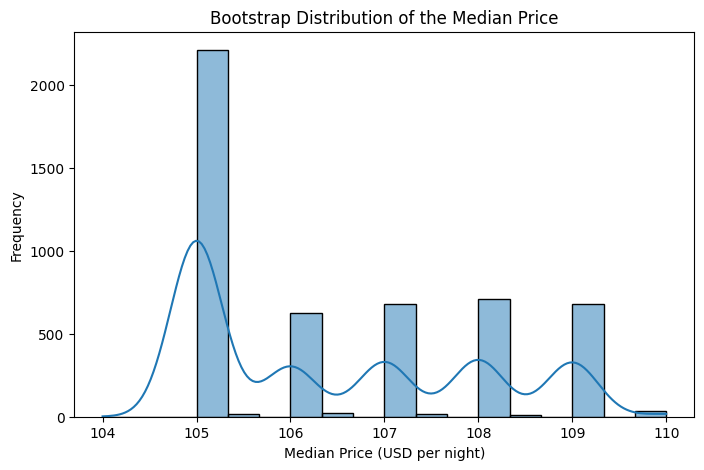

In [ ]:
# Visualize the bootstrap distribution of the median price
plt.figure(figsize=(8, 5))
sns.histplot(bootstrap_values, kde=True)
plt.title('Bootstrap Distribution of the Median Price')
plt.xlabel('Median Price (USD per night)')
plt.ylabel('Frequency')
plt.show()

The median nightly price of Airbnb listings in our sample is 106 USD per night. Using bootstrapping with 5000 resamples we are 95% confident that the true median nightly price of all Airbnb listings in NYC falls between 105 and 109 USD per night.

This is an interesting comparison to our earlier confidence interval for the mean which was between 150.63 and 154.88 USD per night. The median is significantly lower than the mean which confirms that our price data is right skewed  a small number of very expensive listings are pulling the mean upward. The median gives a more accurate picture of what a typical guest actually pays for an Airbnb listing in NYC.

The bootstrap distribution shown above is approximately normal which demonstrates the Central Limit Theorem in action even though individual prices are heavily right skewed the distribution of the sample median becomes approximately normal after repeated resampling.

## Conclusion

This project explored the New York City Airbnb 2019 dataset which contains information on over 48,000 listings across the five boroughs of NYC. Through data cleaning, visualization, and statistical analysis I was able to uncover several interesting patterns about the short term rental market in New York City.

Key findings from this analysis:

- Manhattan has the highest average nightly price followed by Brooklyn and Queens. The Bronx and Staten Island are the most affordable boroughs for Airbnb guests.
- Entire home listings are the most expensive room type averaging around 212 USD per night which is more than double the average price of a private room.
- Budget listings under 100 USD per night make up the majority of listings across NYC with Brooklyn having the highest share of affordable listings at about 50%.
- Airbnb listings in NYC are significantly cheaper than the average hotel room price of 170 USD per night making Airbnb a more affordable option for visitors.
- Room type and borough are not independent meaning certain boroughs tend to have more of a specific room type than others.
- The true median nightly price falls between 105 and 109 USD per night which is significantly lower than the mean of 152 USD confirming that extreme outliers drive the average price upward.
- The bootstrap confidence interval for the median gave a more accurate picture of what a typical guest actually pays for an Airbnb listing in NYC compared to the mean.

Overall this analysis shows that location and room type are the two most important factors that influence Airbnb pricing in New York City. The median price of around 106 USD per night suggests that despite some very expensive listings most Airbnb guests in NYC pay a reasonable and affordable nightly rate.